In [1]:
import pandas as pd

df = pd.read_csv('../data/startup_funding.csv')

df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [2]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Sr No              3044 non-null   int64
 1   Date dd/mm/yyyy    3044 non-null   str  
 2   Startup Name       3044 non-null   str  
 3   Industry Vertical  2873 non-null   str  
 4   SubVertical        2108 non-null   str  
 5   City  Location     2864 non-null   str  
 6   Investors Name     3020 non-null   str  
 7   InvestmentnType    3040 non-null   str  
 8   Amount in USD      2084 non-null   str  
 9   Remarks            419 non-null    str  
dtypes: int64(1), str(9)
memory usage: 237.9 KB


Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64

In [7]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df.rename(columns={'City  Location': 'CityLocation', 'InvestmentnType': 'InvestmentType'}, inplace=True)

df['CityLocation'] = df['CityLocation'].replace('Bangalore', 'Bengaluru')

df['InvestmentType'] = df['InvestmentType'].replace('Seed Funding', 'Seed')
df['InvestmentType'] = df['InvestmentType'].replace('Angel Funding', 'Angel')

print("Unique Cities after cleaning:")
print(df['CityLocation'].unique())

print("\nUnique Investment Types after cleaning:")
print(df['InvestmentType'].unique())

Unique Cities after cleaning:
<StringArray>
[             'Bengaluru',                'Gurgaon',              'New Delhi',
                 'Mumbai',                'Chennai',                   'Pune',
                  'Noida',              'Faridabad',          'San Francisco',
              'San Jose,',
 ...
     'New Delhi/ Houston',        'Mumbai / Global',             'India / US',
        '\\xc2\\xa0Noida',    '\\xc2\\xa0Bangalore',      '\\xc2\\xa0Gurgaon',
    '\\xc2\\xa0New Delhi',       '\\xc2\\xa0Mumbai', 'New Delhi / California',
     'Dallas / Hyderabad']
Length: 112, dtype: str

Unique Investment Types after cleaning:
<StringArray>
[       'Private Equity Round',                    'Series C',
                    'Series B',                'Pre-series A',
                  'Seed Round',                    'Series A',
                    'Series D',                        'Seed',
                    'Series F',                    'Series E',
                'Debt Funding

/var/folders/tc/r_9v6dkj5pj7c0ymq4f7hsyr0000gn/T/ipykernel_83126/3908370554.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [8]:
print(df.columns)

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'CityLocation', 'Investors Name', 'InvestmentType',
       'Amount in USD', 'Remarks'],
      dtype='str')


In [9]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'CityLocation', 'Investors Name', 'InvestmentType',
       'Amount in USD', 'Remarks'],
      dtype='str')


Unique Cities after cleaning:
<StringArray>
[             'Bengaluru',                'Gurgaon',              'New Delhi',
                 'Mumbai',                'Chennai',                   'Pune',
                  'Noida',              'Faridabad',          'San Francisco',
              'San Jose,',
 ...
     'New Delhi/ Houston',        'Mumbai / Global',             'India / US',
        '\\xc2\\xa0Noida',    '\\xc2\\xa0Bangalore',      '\\xc2\\xa0Gurgaon',
    '\\xc2\\xa0New Delhi',       '\\xc2\\xa0Mumbai', 'New Delhi / California',
     'Dallas / Hyderabad']
Length: 112, dtype: str


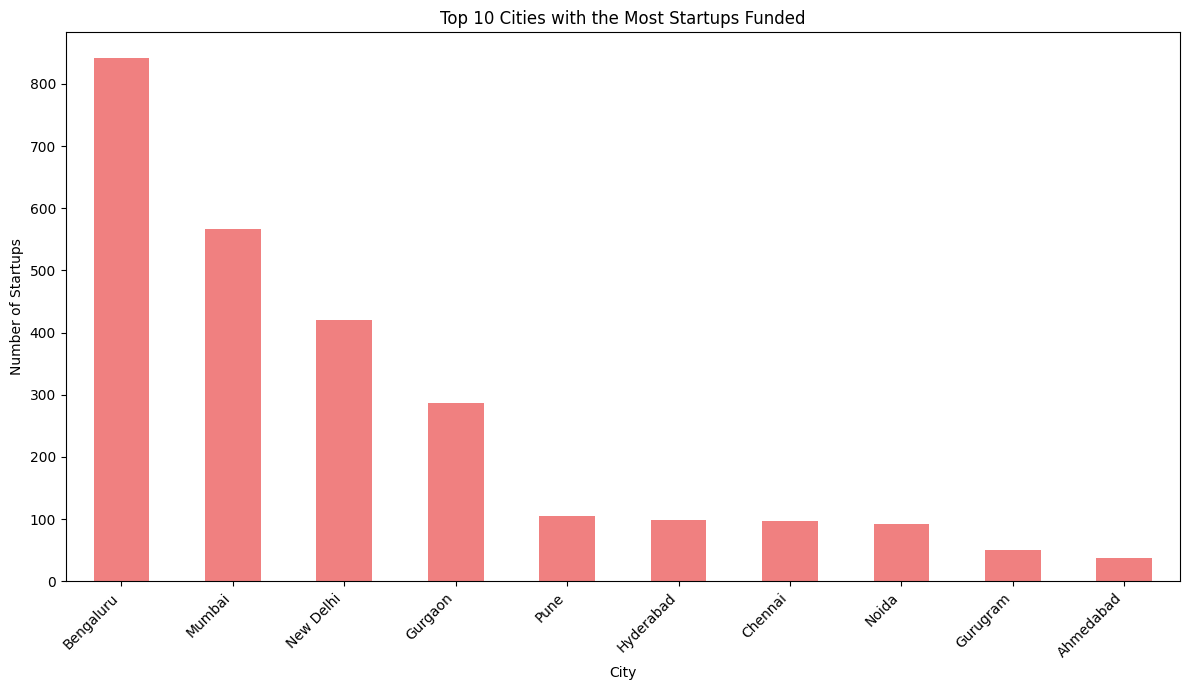

In [12]:
if 'CityLocation' in df.columns:
    df['CityLocation'] = df['CityLocation'].replace('Bangalore', 'Bengaluru')

if 'InvestmentType' in df.columns:
    df['InvestmentType'] = df['InvestmentType'].replace('Seed Funding', 'Seed')
    df['InvestmentType'] = df['InvestmentType'].replace('Angel Funding', 'Angel')

if 'CityLocation' in df.columns:
    print("Unique Cities after cleaning:")
    print(df['CityLocation'].unique())

    startups_per_city = df['CityLocation'].value_counts().head(10)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 7))
    startups_per_city.plot(kind='bar', color='lightcoral')
    plt.title('Top 10 Cities with the Most Startups Funded')
    plt.xlabel('City')
    plt.ylabel('Number of Startups')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()